In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import folium
import ckanapi as ck
import os
from dotenv import load_dotenv

#### API Key Loading
If you don't have an API key, get one here: https://api.data.gov/signup/

This block is just to load in your api key, in order to use it make a file titled '.env' like literally just that, no actual file name just '.env' and put this in there

API_KEY = [insert your api key here]

In [3]:
load_dotenv()
API_KEY = os.getenv('API_KEY')

#### Wrapper Function for Searching CKAN API
I wrote this function for searching the CKAN API since I think it's really annoying to do by hand. Honestly probably don't even need this function but I'm so fed up with the CKAN API that I have this now.

Note about the output of this function: It outputs a giant dictionary that's just a lot of JSON. To actually get the data instead of just more JSON metadata, look any dictionary that has a metadata tag about a **datastore being True** and then find the **package id** and thats how you get the actual data instead of more useless JSON metadata

In [4]:
#Initial CKAN request (I guess a lot of governments use CKAN for their open access data

def search_package(url,query):
    '''
    Queries the CKAN API and returns the results as a JSON Dictionary.

    Args:
        url: CKAN API URL
        query: Query string

    Returns:
        results: JSON Dictionary
    '''

    #Sidenote: I wrote the docstring myself using guidelines from https://www.geeksforgeeks.org/python/python-docstrings/
    #none of my code was written by AI lol
    request = ck.RemoteCKAN(url, apikey=API_KEY)
    result = request.call_action('package_search', {'q':query})
    return result

#### Finding the Actual Data
This entire code block is literally just looking for the actual data instead of the random JSON metadata. The final output of this cell, 'data_dicts' is literally just to display the name of the sub-dataset and the resource ID for it. You need the resource ID to call the actual data, NOT the package ID. The package ID will just spit out a bunch of random metadata no one cares about.

**Also really important note:** I'm actually using a different dataset here: https://data.chhs.ca.gov/dataset/hospital-inpatient-characteristics-by-patient-county-of-residence

The one we talked about using before was the dataset *by facility* meaning by hospital. We don't really need the hospital stuff since we don't really care about the hospital these cases were from, just the county. This dataset also splits all the data into separate files for sex, race, type of care, ect. which is why I made a dictionary to link 9 resource IDs as opposed to just one.

In [5]:
ca_hhs_url = 'https://data.chhs.ca.gov/'
inpatient_query = 'hospital inpatient characteristics - MDC by patient county'
#See above Markdown text to see how I got this ugly subsetting
#If you want to see what I had to look through to get the subsetting, just run the function without any of the bracket stuff
hospital_patient_json = search_package(ca_hhs_url, inpatient_query)['results'][0]['resources'][1:9]

#Making individual lists for the name of the Resource and the Resource ID
data_names = [dct['name'] for dct in hospital_patient_json]
data_ids = [dct['resource_id'] for dct in hospital_patient_json]

#Putting them into one dictionary and calling it
data_dicts = {data_names[i]:data_ids[i] for i in range(len(data_names))}
data_dicts

{'Hospital Inpatient Characteristics - Disposition by Patient County of Residence': '9e6bdf9f-a029-4713-9626-793b20d40ecb',
 'Hospital Inpatient Characteristics - Expected Payer by Patient County of Residence': '6365cd77-61c5-4cda-a6cb-4f052fcf3949',
 'Hospital Inpatient Characteristics - Sex by Patient County of Residence': 'a9eaf75d-f45f-48f1-80d6-493eef9e7968',
 'Hospital Inpatient Characteristics – MS-DRG by Patient County of Residence': '3c3c7db4-dd23-4f98-ad00-779b843b2d45',
 'Hospital Inpatient Characteristics - MDC by Patient County of Residence': '57eaaf0f-6ba9-428a-9498-07070c1e55cc',
 'Hospital Inpatient Characteristics – Race Group by Patient County of Residence': '83a8cd12-434a-4a8d-9721-ca75899568bd',
 'Hospital Inpatient Characteristics – Admission Source by Patient County of Residence': '5ce727f6-7a94-470b-8f27-d340f47d64b0',
 'Hospital Inpatient Characteristics – Type of Care by Patient County of Residence': '58bed582-14ae-4521-b43f-e7682edb0819'}

#### Actually Getting the Data Now
This tiny code block actually pulls the data from the API as opposed to just looking for the information to locate the data. Basically the previous code block was just getting the resource IDs for the stuff we want and this one actually gets the stuff we want. As for the "stuff we want" I just kinda grabbed a few that seem useful, but can add more if needed. Is this making a lot of API calls? Yeah kinda. Do we need to make them more than once ever? No so it should be fine I hope lol.

In [6]:
data_request = ck.RemoteCKAN('https://data.chhs.ca.gov/', apikey=API_KEY)
MDC_data_dict = data_request.call_action('datastore_search', {'resource_id':'57eaaf0f-6ba9-428a-9498-07070c1e55cc',
                                              'limit':32000})
sex_data_dict = data_request.call_action('datastore_search', {'resource_id':'a9eaf75d-f45f-48f1-80d6-493eef9e7968',
                                              'limit':32000})
race_data_dict = data_request.call_action('datastore_search', {'resource_id':'83a8cd12-434a-4a8d-9721-ca75899568bd',
                                              'limit':32000})
care_data_dict = data_request.call_action('datastore_search', {'resource_id':'58bed582-14ae-4521-b43f-e7682edb0819',
                                              'limit':32000})

#### Pandas Data Cleanup
Just a bunch of pandas data cleaning, not really important to look at tbh but if you want it explained later just lmk

In [15]:
def inpatient_data_cleanup(dct, year, drops = None, renames=None, inpatient_data_used = False):
    '''
    Takes a dict of JSON data and converts it into a pandas dataframe, dropping list specified columns and renaming columns specified by rename_key_dict.

    Parameters:
        dct: Dict of JSON data
        drops: Optional list of column names to drop
        renames: Optional dict of column names to rename
        year

    Returns:
        Pandas dataframe
    '''

    if inpatient_data_used:
        if (renames is not None and type(renames) is dict):
            renames = renames | {'dsch_yr':'Year', 'patcnty1':'County'}
        else:
            renames = {'dsch_yr':'Year', 'patcnty1':'County'}
        if (drops is not None and type(drops) is list):
            drops = drops + ['_id']
        else:
            drops = ['_id']

    df = pd.DataFrame(dct['records'])

    if drops is not None and type(drops) is list:
        df = df.drop(columns= drops)
    elif drops is not None and type(drops) is not list:
        raise TypeError('drops must be a list')

    if type(renames) is dict and renames is not None:
        df = df.rename(columns=renames)
    elif type(renames) != dict and renames is not None:
        raise TypeError('renames must be a dictionary or use string "inpatient_default" for inpatient data default!')


    if (year >= 2012 or year <= 2024) and type(year) is int:
        if (renames == 'default' or type(renames) is dict):
            df['Year'] = df['Year'].apply(pd.to_numeric)
            df = df[df['Year'] == year]
        else:
            df['dsch_yr'] = df['dsch_yr'].apply(pd.to_numeric)
            df = df[df['dsch_yr'] == year]
    elif type(year) is not int:
        raise TypeError('year must be an integer!')
    elif year < 2012 or year > 2024:
        raise ValueError('year must be between 2012 and 2024!')

    return df

In [12]:
MDC_data = inpatient_data_cleanup(MDC_data_dict, 2024, ['AnnotationCode','AnnotationDesc','_id','mdc'], {'mdc_desc':'MDC', 'dsch_yr':'Year'}, inpatient_data_used=True)
MDC_data[(MDC_data['MDC'] == 'NERVOUS SYSTEM, DISEASES & DISORDERS') |
         (MDC_data['MDC'] == 'RESPIRATORY SYSTEM, DISEASES & DISORDERS') |
         (MDC_data['MDC'] == 'CIRCULATORY SYSTEM, DISEASES & DISORDERS') |
         (MDC_data['MDC'] == 'DIGESTIVE SYSTEM, DISEASES & DISORDERS')]

,County,Year,MDC,Discharges
312,Alameda,2024,"NERVOUS SYSTEM, DISEASES & DISORDERS",9125
315,Alameda,2024,"RESPIRATORY SYSTEM, DISEASES & DISORDERS",9254
316,Alameda,2024,"CIRCULATORY SYSTEM, DISEASES & DISORDERS",13941
317,Alameda,2024,"DIGESTIVE SYSTEM, DISEASES & DISORDERS",8593
474,Alpine,2024,"NERVOUS SYSTEM, DISEASES & DISORDERS",4
...,...,...,...,...
18928,Yolo,2024,"DIGESTIVE SYSTEM, DISEASES & DISORDERS",1247
19252,Yuba,2024,"NERVOUS SYSTEM, DISEASES & DISORDERS",629
19255,Yuba,2024,"RESPIRATORY SYSTEM, DISEASES & DISORDERS",660
19256,Yuba,2024,"CIRCULATORY SYSTEM, DISEASES & DISORDERS",1143


In [16]:
sex_data = inpatient_data_cleanup(sex_data_dict, 2024, drops = ['AnnotationCode','AnnotationDesc','_id'], inpatient_data_used=True)
sex_data

,County,Year,Sex,Discharges
36,Alameda,2024,Female,71064
37,Alameda,2024,Male,56894
38,Alameda,2024,"Unknown, Invalid",27
63,Alpine,2024,Female,NaN
64,Alpine,2024,Male,NaN
...,...,...,...,...
1981,Yolo,2024,Male,7633
1982,Yolo,2024,"Unknown, Invalid",4
2010,Yuba,2024,Female,5368
2011,Yuba,2024,Male,4073


In [17]:
race_data = inpatient_data_cleanup(race_data_dict, 2024, ['AnnotationCode','AnnotationDesc','_id'], {'race_grp1':'Race'}, inpatient_data_used=True)
race_data

,County,Year,Race,Discharges
99,Alameda,2024,American Indian/Alaska Native,269
100,Alameda,2024,Asian,28727
101,Alameda,2024,Black,22319
102,Alameda,2024,Hispanic,27218
103,Alameda,2024,Invalid/Blank,10
...,...,...,...,...
6105,Yuba,2024,Multi-racial,81
6106,Yuba,2024,Native Hawaiian/Other Pacific Islander,52
6107,Yuba,2024,Other,339
6108,Yuba,2024,Unknown,127


In [18]:
care_data = inpatient_data_cleanup(care_data_dict, 2024, ['_id'], {'typcare1':'Care'}, inpatient_data_used=True)
care_data

,County,Year,Care,Discharges
64,Alameda,2024,Acute Care,120153
65,Alameda,2024,Chemical Dependency Recovery Care,85
66,Alameda,2024,Invalid/Blank,14
67,Alameda,2024,Physical Rehabilitation Care,1375
68,Alameda,2024,Psychiatric Care,5740
...,...,...,...,...
3855,Yuba,2024,Acute Care,8873
3856,Yuba,2024,Chemical Dependency Recovery Care,2
3857,Yuba,2024,Physical Rehabilitation Care,93
3858,Yuba,2024,Psychiatric Care,424


#### Issue

Big problem now: I think all of the api stuff I just did was completely pointless. I used the other dataset (by county instead of by facility) because it has an api endpoint, unlike the facility one, except it only has *discharge* data, not data on the actual occupancy and doesn't include deaths. The facility one has all that data and even more but it doesn't have an API endpoint. In the next code block I'll clean up the excel data from the facility data but import it into python by just downloading the excel file.

Note: The facility data does actually have an api endpoint, but its all from 2021 or before, meaning we either have to choose to use very outdated data or use data heavily biased by the COVID-19 pandemic.

In [ ]:
def facility_data_county_selector(df,filter):
    '''
    Takes a the raw facility dataframe and list of wanted variables and filters out everything but wanted variables aand groups by county.

    Parameters:
        df: The Facility Data dataframe
        filter: A list of variables you want from the dataframe

    Returns:
        Pandas dataframe grouped by county
    '''
    if type(filter) is list:
        filter = filter
    else:
        filter = list(filter)
    filter = ['COUNTY'] + filter
    df = df.filter(items = filter)
    for var in list(df.columns)[1:len(df.columns)]:
        df[var] = df[var].apply(pd.to_numeric)
        df[var] = df.groupby('COUNTY')[var].transform('sum')
    df = df.drop_duplicates()
    return df
def facility_data_by_region(df,regions):
    

C:\Users\zchanedu\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,COUNTY,Age_0_09,Age_10_19,Age_20_29,Age_30_39,Age_40_49,Age_50_59,Age_60_69,Age_70_79,Age_80_,Age_Other_Unknown
0,ALAMEDA,21775.0,7686.0,10605.0,18809.0,10601.0,12349.0,18971.0,20076.0,20259.0,43.0
18,AMADOR,220.0,0.0,156.0,178.0,118.0,203.0,465.0,574.0,636.0,9.0
19,BUTTE,2735.0,403.0,2357.0,3092.0,2630.0,3641.0,6283.0,6413.0,5650.0,27.0
23,CALAVERAS,0.0,0.0,13.0,42.0,61.0,99.0,211.0,232.0,253.0,5.0
24,COLUSA,0.0,0.0,14.0,55.0,53.0,128.0,160.0,141.0,161.0,1.0
25,CONTRA COSTA,11232.0,2579.0,5480.0,10461.0,5573.0,7337.0,11884.0,13802.0,14963.0,12.0
33,DEL NORTE,263.0,46.0,186.0,200.0,168.0,237.0,423.0,432.0,344.0,0.0
34,EL DORADO,682.0,69.0,532.0,736.0,530.0,612.0,1148.0,1358.0,1283.0,1.0
37,FRESNO,16045.0,2096.0,12530.0,15198.0,10287.0,12132.0,16635.0,15993.0,13206.0,17.0
47,GLENN,0.0,0.0,0.0,12.0,13.0,27.0,66.0,105.0,113.0,1.0


In [107]:
facility_data = pd.read_excel('./data/2024pddpivot.xlsx', sheet_name='Data')
facility_data_groups = {'sex':["Sex_Male", 'Sex_Female', 'Sex_Other_Unknown'],
                        'age':['Age_0_09', 'Age_10_19', 'Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_', 'Age_Other_Unknown'],
                        'ethnicity':['eth_Hispanic', 'eth_NonHispanic', 'eth_Other_Unknown'],
                        'race':['racegrp_aman', 'racegrp_asian', 'racegrp_nhpi', 'racegrp_black', 'racegrp_white', 'racegrp_unknown', 'racegrp_other', 'racegrp_multirace'],
                        'diagnosis_group':['dx_Infectious', 'dx_Circulatory', 'dx_Respiratory', 'dx_Digestive', 'dx_Infectious', 'dx_Skin', 'dx_MentalHealth']}

demographic_facility_data = {k:facility_data_county_selector(facility_data,facility_data_groups[k]) for k in facility_data_groups}
demographic_facility_data = {k:demographic_facility_data[k].assign(Total = demographic_facility_data[k].drop(labels = 'COUNTY', axis=1).sum(axis=1)) for k in facility_data_groups}



C:\Users\zchanedu\AppData\Roaming\Python\Python314\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


#### Some Plots!
omg finally starting to make plots and visualizations! I'm gonna try and mostly use seaborn since I like the look of seaborn plots the most. Will maybe make a map soon.

I think map and API plan right now is to pivot back to the grocery store thing? Like maybe try to use an api to get the location of grocery stores and use that data to make a choropleth dot map over a region map with the color gradient corrosponding to whatever variable.

<Axes: xlabel='Percent', ylabel='Density'>

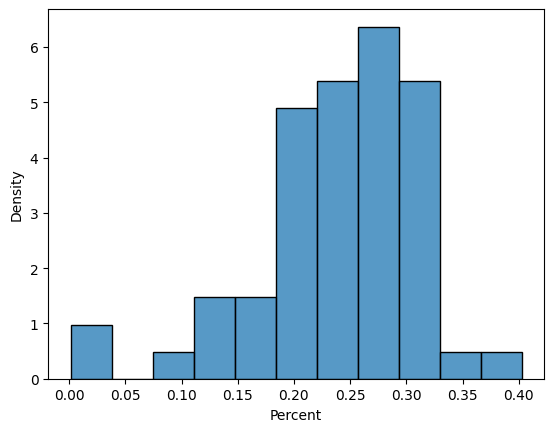

In [106]:
circulatory_data_tidy = demographic_facility_data['diagnosis_group'].filter(items=['COUNTY','dx_Circulatory','Total'])
circulatory_data_tidy = circulatory_data_tidy.assign(Percent = lambda x: x['dx_Circulatory']/x['Total'])
circulatory_data_tidy
sns.histplot(circulatory_data_tidy, x='Percent', stat='density')